# Portfolio Bootstrap Analysis (Comparison)

This notebook analyzes two hedge fund datasets (`time_series_jpm_renamed.csv` and `HFR_2000.csv`) to:
1. Filter funds with complete data from 2020 to end of 2025.
2. Randomly select funds to form portfolios based on multiple weighting schemes (Equal Weight and Inverse Volatility).
3. Compute numerous performance metrics, including basic returns, ratios, drawdowns, captures, and regressions against the S&P 500.
4. Bootstrap this process 1000 times for both datasets, using multiple workers and displaying progress via `tqdm`.
5. Overlay the distributions and scaling plots to directly compare the two datasets.

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

plt.style.use('seaborn-v0_8-whitegrid')

In [159]:
# Load data
df_jpm = pd.read_csv('data/time_series_jpm_renamed.csv', index_col=0, parse_dates=True)
df_hfr = pd.read_csv('data/HFR_2000.csv', index_col=0, parse_dates=True)

# Load S&P 500 data
sp500 = pd.read_csv('data/hf_returns/sp500.csv', index_col=0, parse_dates=True)

# Filter for the date range: 2020-01-01 to 2025-12-31
start_date = '2020-01-01'
end_date = '2025-12-31'

# Slice the data and drop columns with NaNs
jpm_period = df_jpm.loc[start_date:end_date].dropna(axis=1, how='any')
hfr_period = df_hfr.loc[start_date:end_date].dropna(axis=1, how='any')
sp500_period = sp500.loc[start_date:end_date]['SP500TR']

print(f"JPM funds with complete data from {start_date} to {end_date}: {jpm_period.shape[1]}")
print(f"HFR funds with complete data from {start_date} to {end_date}: {hfr_period.shape[1]}")

JPM funds with complete data from 2020-01-01 to 2025-12-31: 348
HFR funds with complete data from 2020-01-01 to 2025-12-31: 354


In [160]:
def calculate_metrics(returns, sp500_returns):
    """
    Calculate comprehensive portfolio metrics from a series of monthly returns.
    """
    # 1. Mean Return (Annualized) %
    mean_return_ann = returns.mean() * 12 * 100
    
    # 2. CAGR %
    cum_return = (1 + returns).prod()
    n_years = len(returns) / 12
    cagr = (cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan) * 100
    
    # 3. Volatility (Annualized) %
    volatility = returns.std() * np.sqrt(12) * 100
    
    # 4. Sharpe Ratio (Annualized)
    sharpe_ratio_ann = (returns.mean() / returns.std() * np.sqrt(12)) if returns.std() != 0 else np.nan
    
    # 5. Max Drawdown %
    cum_index = (1 + returns).cumprod()
    running_max = cum_index.cummax()
    drawdown = (cum_index - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # 6. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    # 7. Correlation with S&P 500
    correlation = returns.corr(sp500_returns)
    
    # 8. Proportion of Positive Months %
    pos_months = (returns > 0).mean() * 100
    
    # 9. Upside / Downside Capture (%)
    up_idx = sp500_returns > 0
    down_idx = sp500_returns < 0
    
    port_up_ret = (1 + returns[up_idx]).prod() - 1
    sp500_up_ret = (1 + sp500_returns[up_idx]).prod() - 1
    up_capture = (port_up_ret / sp500_up_ret * 100) if sp500_up_ret != 0 else np.nan
    
    port_down_ret = (1 + returns[down_idx]).prod() - 1
    sp500_down_ret = (1 + sp500_returns[down_idx]).prod() - 1
    down_capture = (port_down_ret / sp500_down_ret * 100) if sp500_down_ret != 0 else np.nan
    
    # 10. Correlation when S&P500 is below its 1st quartile
    q1_sp500 = sp500_returns.quantile(0.25)
    below_q1_idx = sp500_returns < q1_sp500
    corr_below_q1 = returns[below_q1_idx].corr(sp500_returns[below_q1_idx])
    
    # 11. Regression Metrics (Alpha, Beta, R2, t-stats)
    y = returns.values
    x = sp500_returns.values
    n = len(x)
    
    cov_matrix = np.cov(x, y)
    beta = cov_matrix[0, 1] / cov_matrix[0, 0] if cov_matrix[0, 0] != 0 else np.nan
    alpha = np.mean(y) - beta * np.mean(x)
    
    y_pred = alpha + beta * x
    residuals = y - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    r2 = (1 - (ss_res / ss_tot)) * 100 if ss_tot != 0 else np.nan
    
    s_err = np.sqrt(ss_res / (n - 2)) if n > 2 else np.nan
    ss_xx = np.sum((x - np.mean(x))**2)
    
    beta_se = s_err / np.sqrt(ss_xx) if ss_xx != 0 else np.nan
    alpha_se = s_err * np.sqrt(1/n + (np.mean(x)**2) / ss_xx) if ss_xx != 0 else np.nan
    
    beta_tstat = beta / beta_se if beta_se != 0 and not np.isnan(beta_se) else np.nan
    alpha_tstat = alpha / alpha_se if alpha_se != 0 and not np.isnan(alpha_se) else np.nan
    
    # Annualized Alpha (converted to %)
    alpha_ann = ((1 + alpha)**12 - 1) * 100
    
    return {
        'Mean Return (Ann) %': mean_return_ann,
        'CAGR %': cagr,
        'Volatility (Ann) %': volatility,
        'Sharpe Ratio (Ann)': sharpe_ratio_ann,
        'Max Drawdown %': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Correlation with SP500': correlation,
        'Positive Months %': pos_months,
        'Upside Capture %': up_capture,
        'Downside Capture %': down_capture,
        'Correlation (SP500 < Q1)': corr_below_q1,
        'Beta': beta,
        'Beta t-stat': beta_tstat,
        'Alpha (Ann) %': alpha_ann,
        'Alpha t-stat': alpha_tstat,
        'R-squared %': r2
    }

In [161]:
def bootstrap_worker(data_df, sp500_series, n, weight_scheme):
    """Worker function to process a single bootstrap iteration."""
    cols = data_df.columns.tolist()
    sel = np.random.choice(cols, size=n, replace=False)
    returns_subset = data_df[sel]
    
    if weight_scheme == 'ew':
        weights = np.ones(n) / n
    elif weight_scheme == 'iv':
        vols = returns_subset.std()
        # Handle zero vol to avoid divide-by-zero
        vols = vols.replace(0, np.nan)
        inv_vols = 1.0 / vols
        weights = inv_vols / inv_vols.sum()
        weights = weights.fillna(1.0 / n).values
        
    port_ret = (returns_subset * weights).sum(axis=1)
    return calculate_metrics(port_ret, sp500_series)

def run_bootstrap_n(data_df, sp500_series, n, n_boot=1000, weight_scheme='ew'):
    """
    Runs the bootstrap simulation utilizing a ThreadPoolExecutor for concurrent multi-worker processing.
    """
    res = []
    if len(data_df.columns) < n:
        return pd.DataFrame()
        
    # Safest parallelization inside a Jupyter Notebook on MacOS avoids full Process pooling issues,
    # and many numpy operations natively drop the GIL regardless.
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(bootstrap_worker, data_df, sp500_series, n, weight_scheme) for _ in range(n_boot)]
        
        for future in tqdm(as_completed(futures), total=n_boot, desc=f"Bootstrap n={n} ({weight_scheme.upper()})", leave=False):
            res.append(future.result())
            
    return pd.DataFrame(res)

metrics_to_plot = [
    'Mean Return (Ann) %', 
    'CAGR %', 
    'Volatility (Ann) %', 
    'Sharpe Ratio (Ann)', 
    'Max Drawdown %', 
    'Calmar Ratio', 
    'Correlation with SP500',
    'Positive Months %',
    'Upside Capture %',
    'Downside Capture %',
    'Correlation (SP500 < Q1)',
    'Beta',
    'Beta t-stat',
    'Alpha (Ann) %',
    'Alpha t-stat',
    'R-squared %'
]

In [162]:
# Setup Plotting Helpers to avoid code duplication

def plot_distributions(res_jpm_10, res_hfr_10, title_prefix=""):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        # JPM Data
        if not res_jpm_10.empty:
            d_jpm = res_jpm_10[metric].dropna()
            ax.hist(d_jpm, bins=30, color='skyblue', edgecolor='black', alpha=0.5, label='JPM Data')
            med_jpm = d_jpm.median()
            ax.axvline(med_jpm, color='blue', linestyle='dashed', linewidth=2, label=f'JPM Med: {med_jpm:.2f}')
            
        # HFR Data
        if not res_hfr_10.empty:
            d_hfr = res_hfr_10[metric].dropna()
            ax.hist(d_hfr, bins=30, color='orange', edgecolor='black', alpha=0.5, label='HFR Data')
            med_hfr = d_hfr.median()
            ax.axvline(med_hfr, color='red', linestyle='dashed', linewidth=2, label=f'HFR Med: {med_hfr:.2f}')
        
        ax.set_title(f'{title_prefix} Distribution of {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
        ax.legend()

    # Hide any unused subplots
    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


def run_scaling_analysis(jpm_period, hfr_period, sp500_period, weight_scheme='ew'):
    n_values = range(3, 16)
    q_results_jpm = {m: [] for m in metrics_to_plot}
    q_results_hfr = {m: [] for m in metrics_to_plot}

    for n in tqdm(n_values, desc=f"Scaling sizes ({weight_scheme.upper()})"):
        df_n_jpm = run_bootstrap_n(jpm_period, sp500_period, n, n_boot=1000, weight_scheme=weight_scheme)
        df_n_hfr = run_bootstrap_n(hfr_period, sp500_period, n, n_boot=1000, weight_scheme=weight_scheme)
        
        for m in metrics_to_plot:
            # Use Q1 for downside capture, beta, R2, and correlations. Use Q3 for all others.
            q1_metrics = ['Correlation with SP500', 'Correlation (SP500 < Q1)', 'Downside Capture %', 'Beta', 'R-squared %']
            q_target = 0.25 if m in q1_metrics else 0.75
            
            q_results_jpm[m].append(df_n_jpm[m].quantile(q_target) if not df_n_jpm.empty else np.nan)
            q_results_hfr[m].append(df_n_hfr[m].quantile(q_target) if not df_n_hfr.empty else np.nan)

    return pd.DataFrame(q_results_jpm, index=n_values), pd.DataFrame(q_results_hfr, index=n_values)

def plot_scaling(df_q_jpm, df_q_hfr, title_prefix=""):
    n_values = df_q_jpm.index
    nrows_scale = int(np.ceil(len(metrics_to_plot) / 3))
    fig, axes = plt.subplots(nrows_scale, 3, figsize=(18, 5 * nrows_scale))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        ax.plot(df_q_jpm.index, df_q_jpm[metric], marker='o', linestyle='-', color='blue', linewidth=2, label='JPM Data')
        ax.plot(df_q_hfr.index, df_q_hfr[metric], marker='s', linestyle='-', color='red', linewidth=2, label='HFR Data')
        
        q1_metrics = ['Correlation with SP500', 'Correlation (SP500 < Q1)', 'Downside Capture %', 'Beta', 'R-squared %']
        q_label = "Q1" if metric in q1_metrics else "Q3"
        
        ax.set_title(f'{title_prefix} {metric} ({q_label}) vs. Size')
        ax.set_xlabel('Number of Funds (n)')
        ax.set_ylabel(f'{q_label} Value')
        ax.set_xticks(list(n_values))
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()

    for i in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

## 1. Equal-Weight Portfolio Analysis
Weights are distributed evenly across the `n` randomly selected funds.

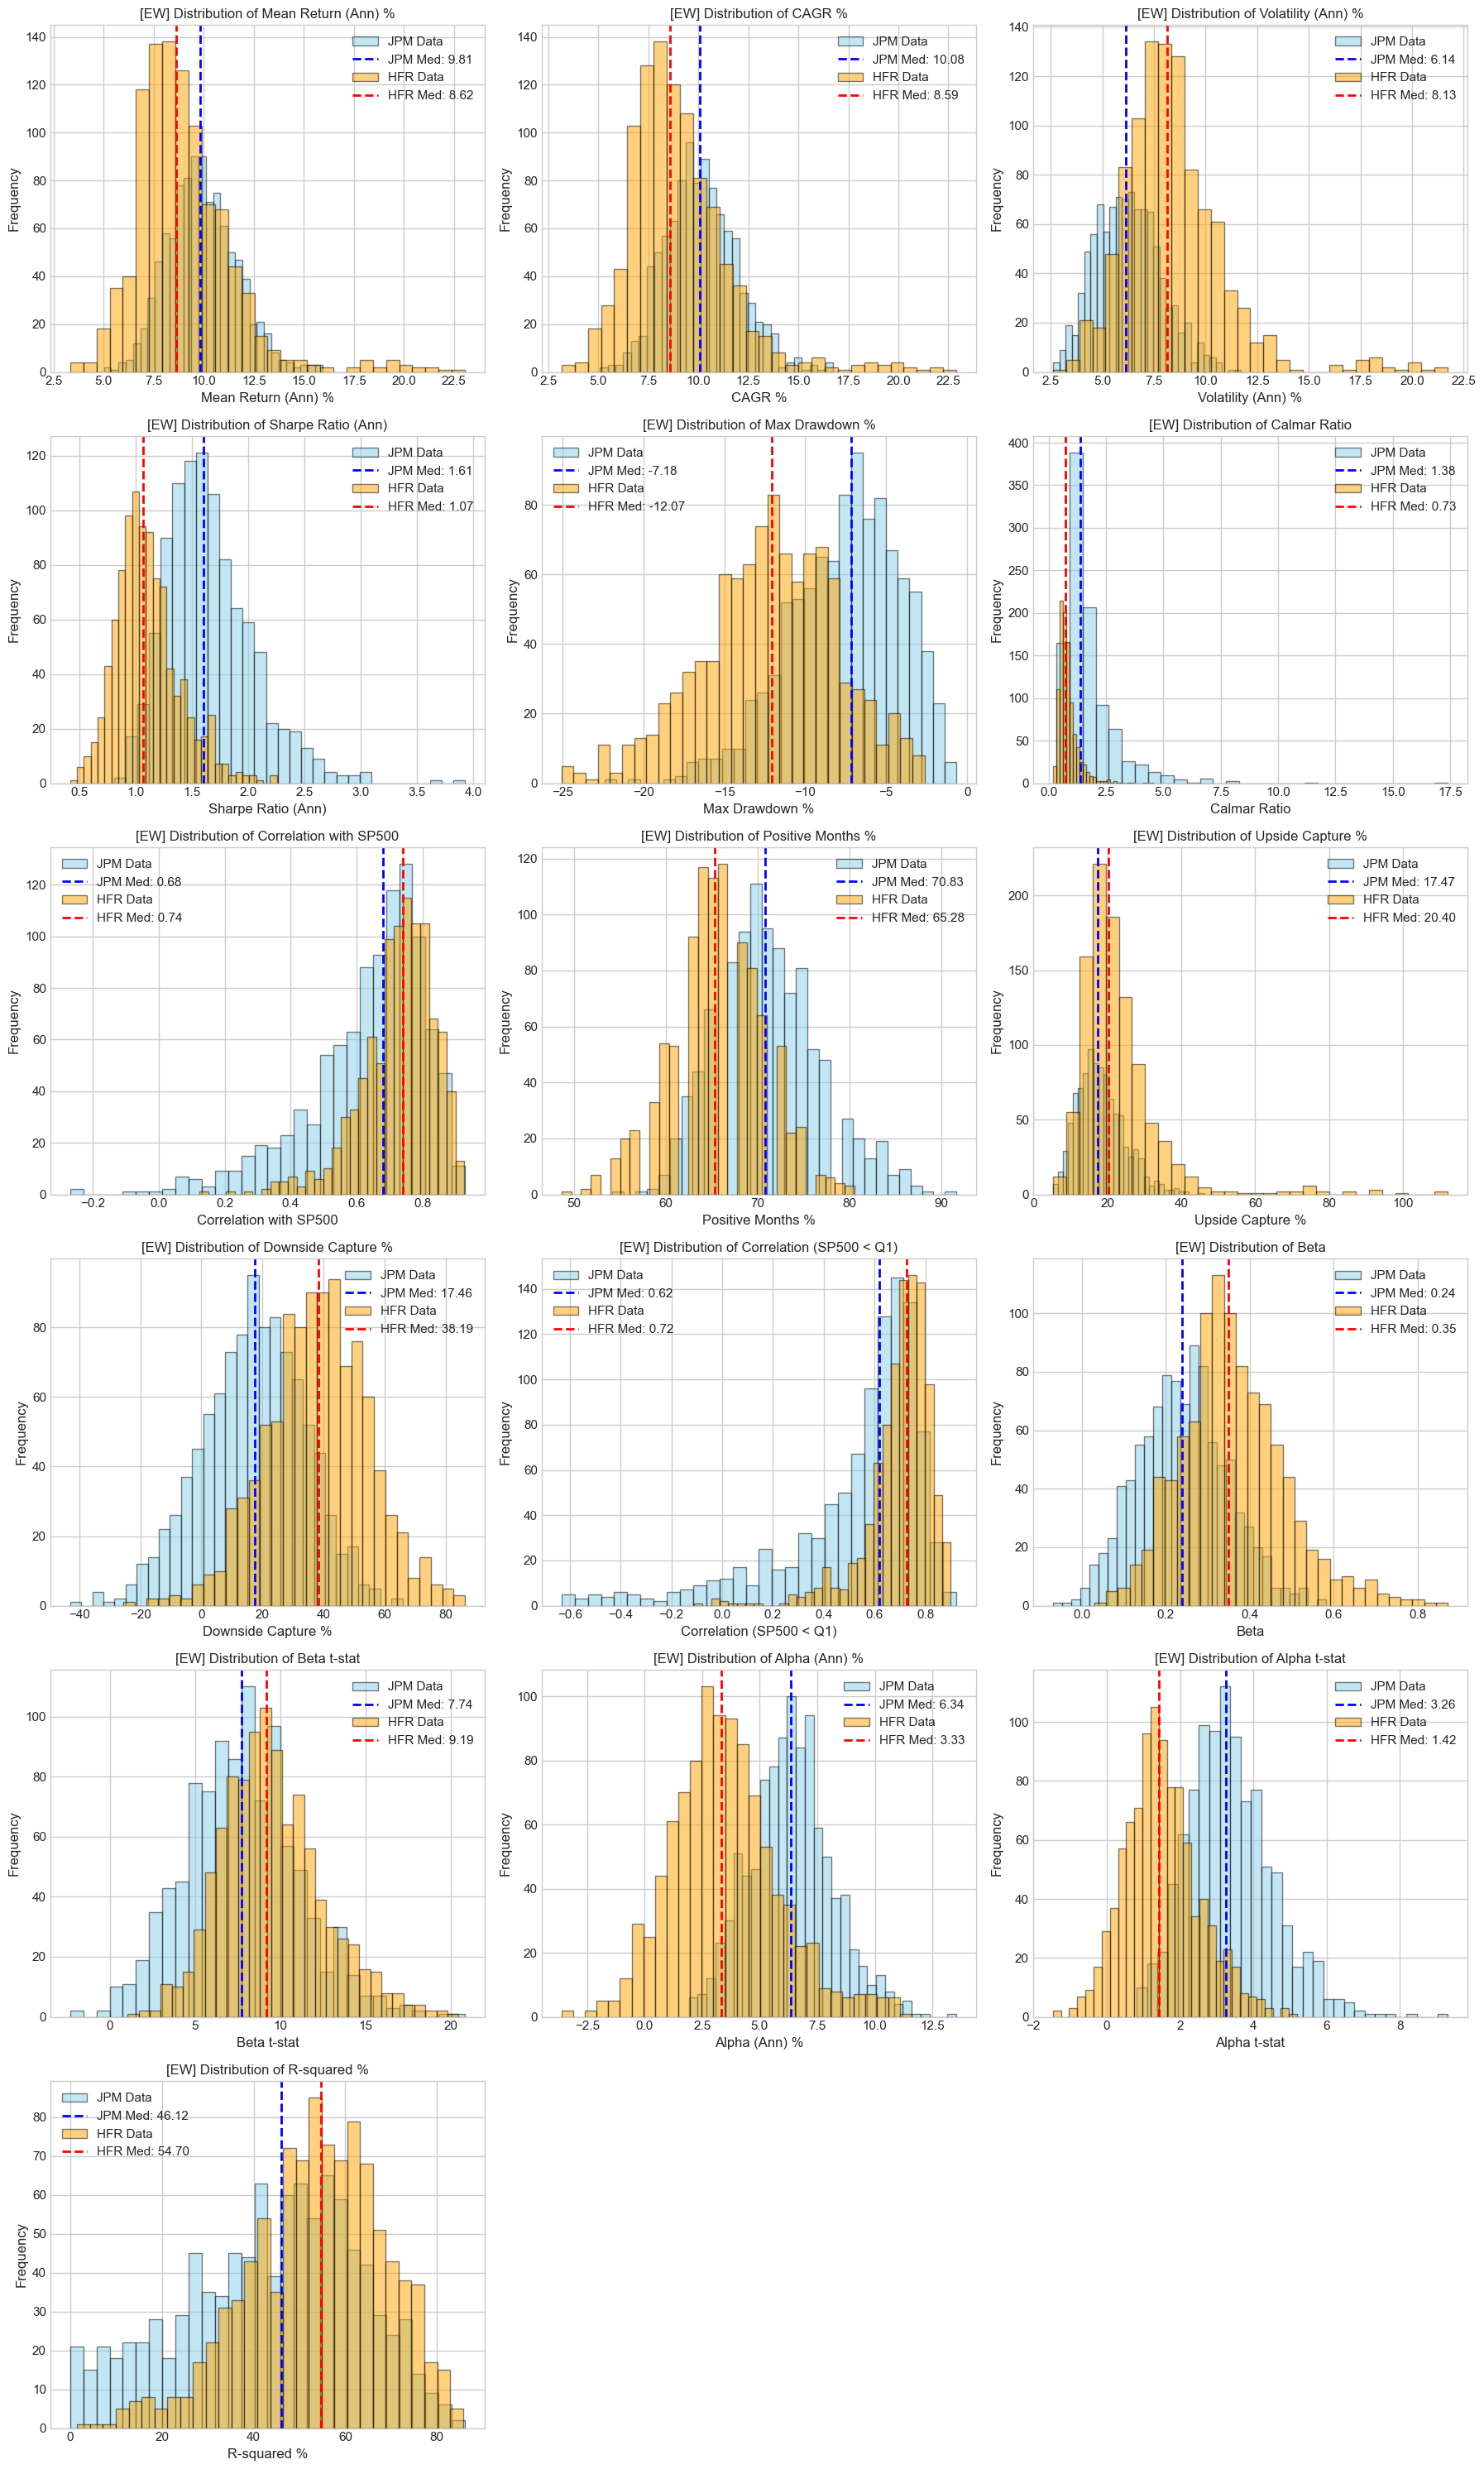

In [163]:
np.random.seed(42)
res_jpm_10_ew = run_bootstrap_n(jpm_period, sp500_period, 10, n_boot=1000, weight_scheme='ew')
res_hfr_10_ew = run_bootstrap_n(hfr_period, sp500_period, 10, n_boot=1000, weight_scheme='ew')

plot_distributions(res_jpm_10_ew, res_hfr_10_ew, title_prefix="[EW]")

Scaling sizes (EW): 100%|██████████| 13/13 [00:29<00:00,  2.24s/it]


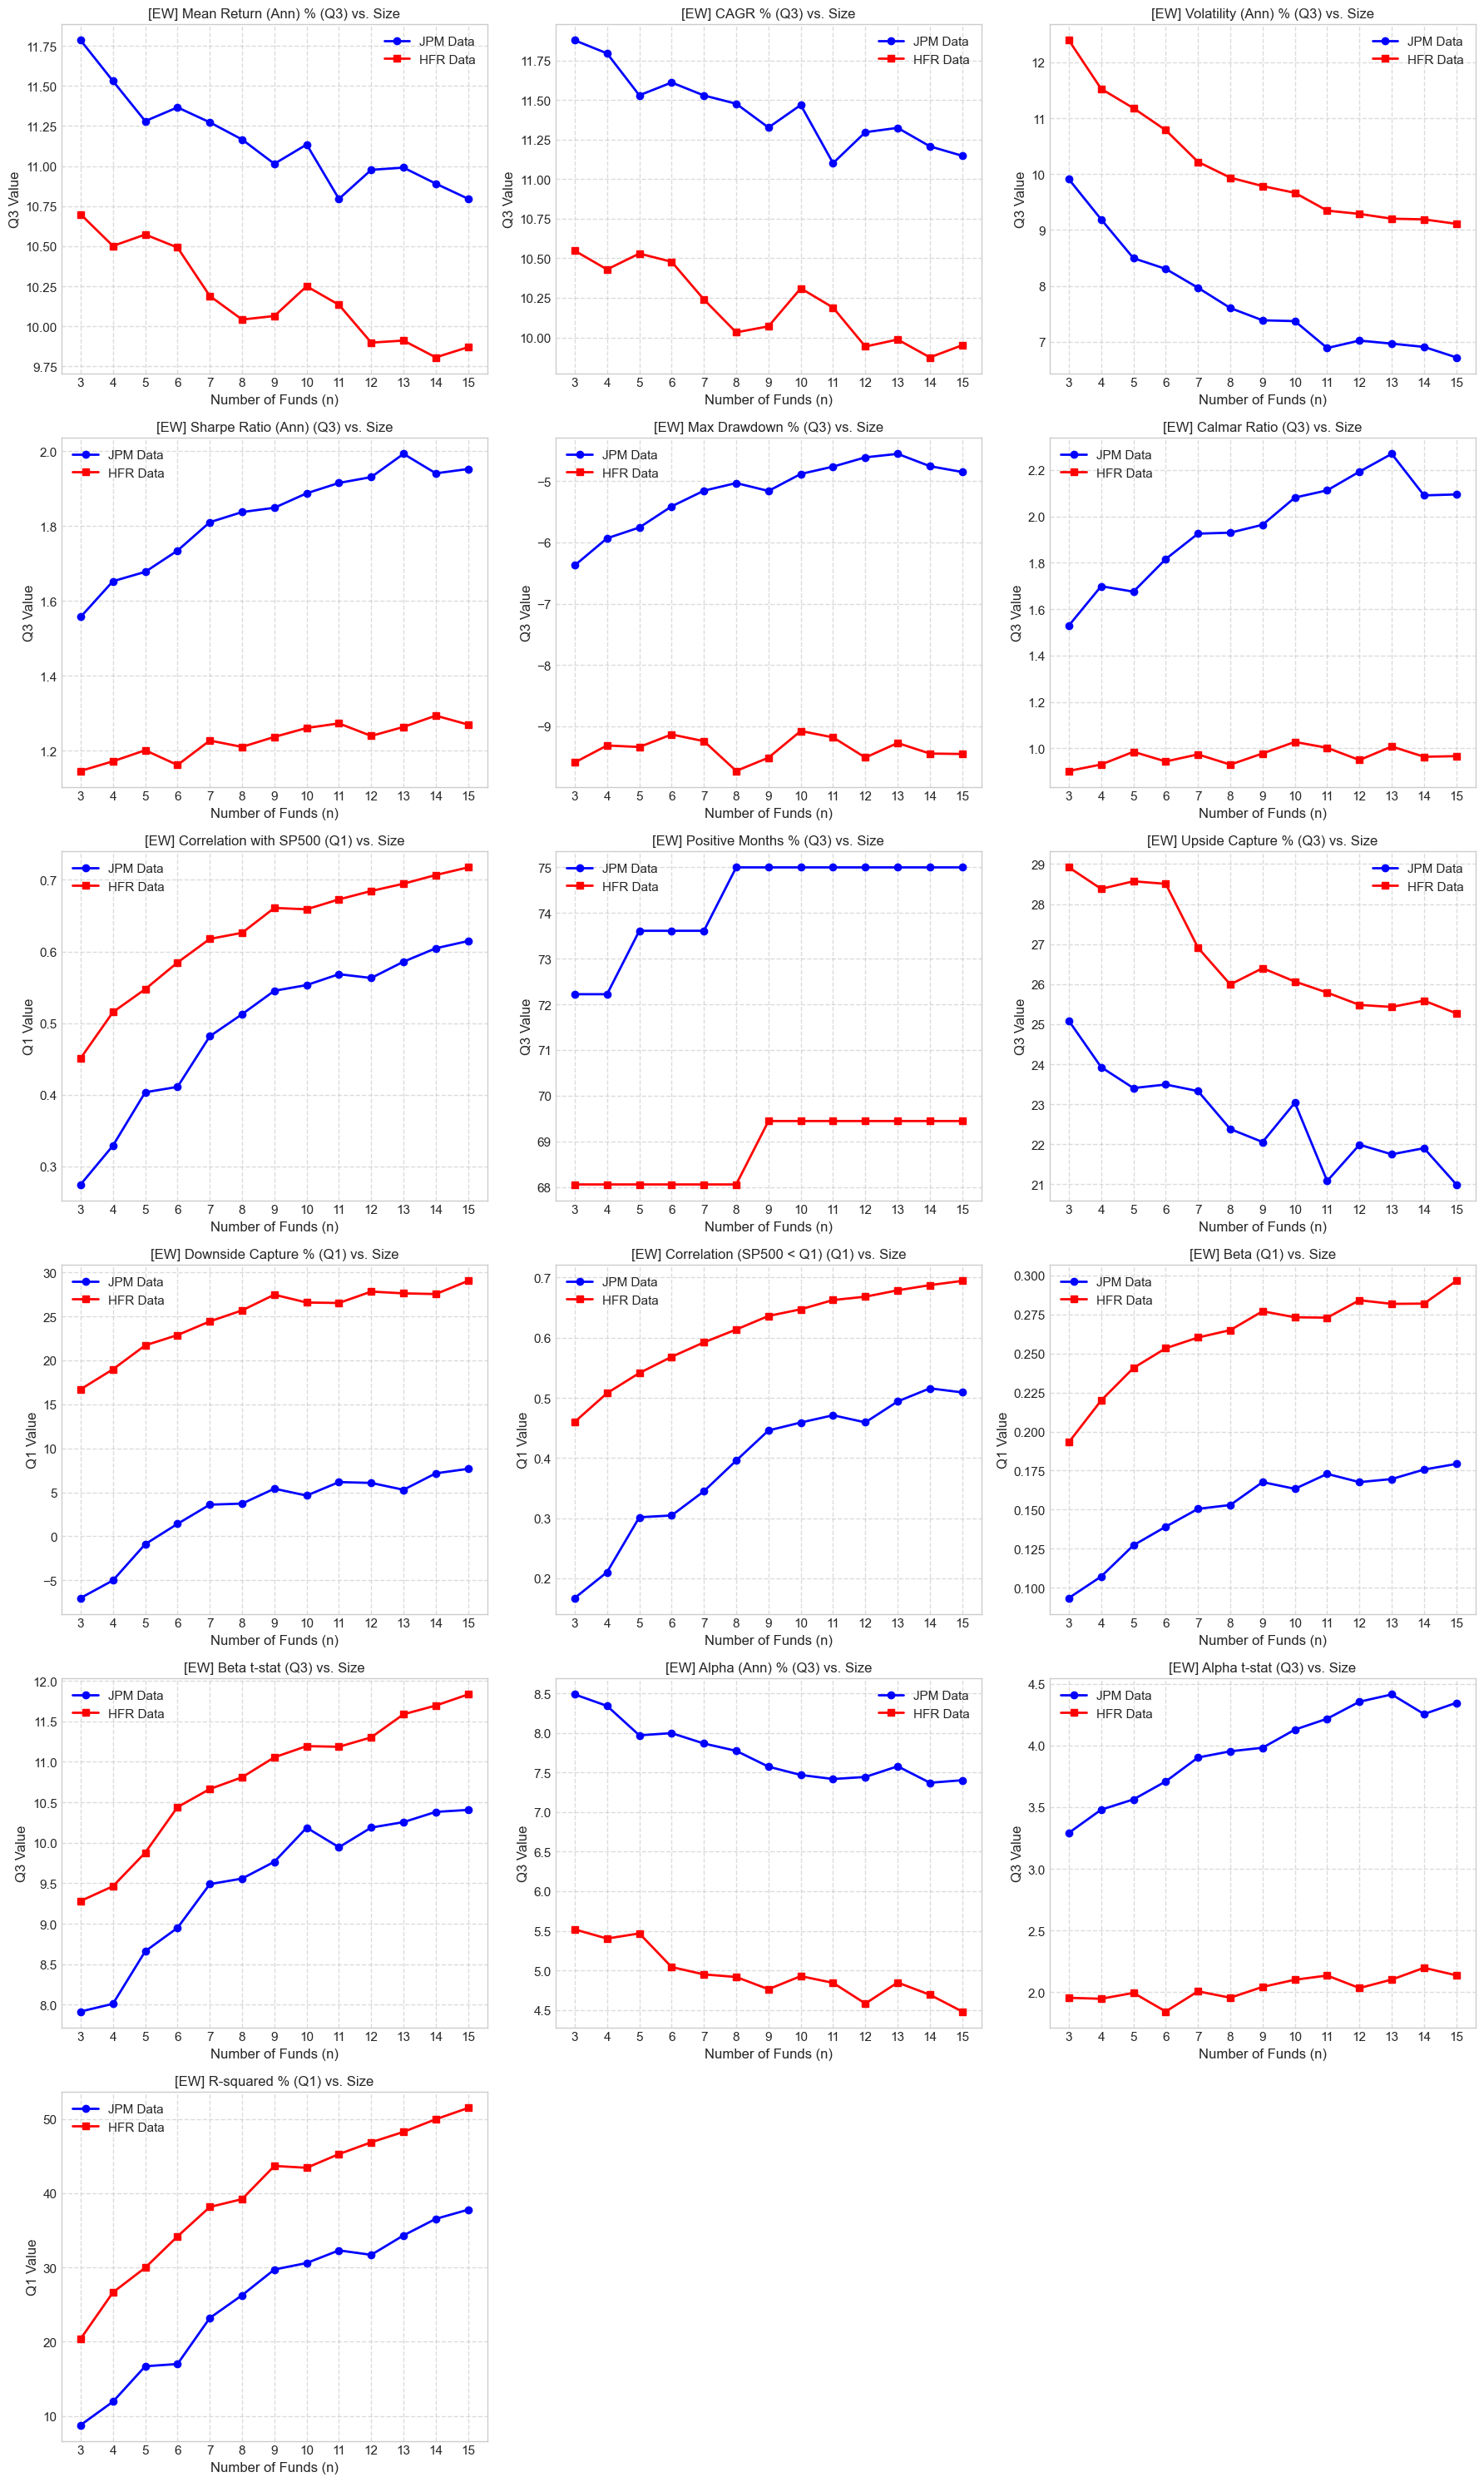

In [164]:
np.random.seed(42)
df_q_jpm_ew, df_q_hfr_ew = run_scaling_analysis(jpm_period, hfr_period, sp500_period, weight_scheme='ew')
plot_scaling(df_q_jpm_ew, df_q_hfr_ew, title_prefix="[EW]")

## 2. Inverse Volatility Portfolio Analysis
Weights are calculated inversely proportional to the volatility (standard deviation) of the funds over the analyzed period. Funds with lower volatility get higher allocations.

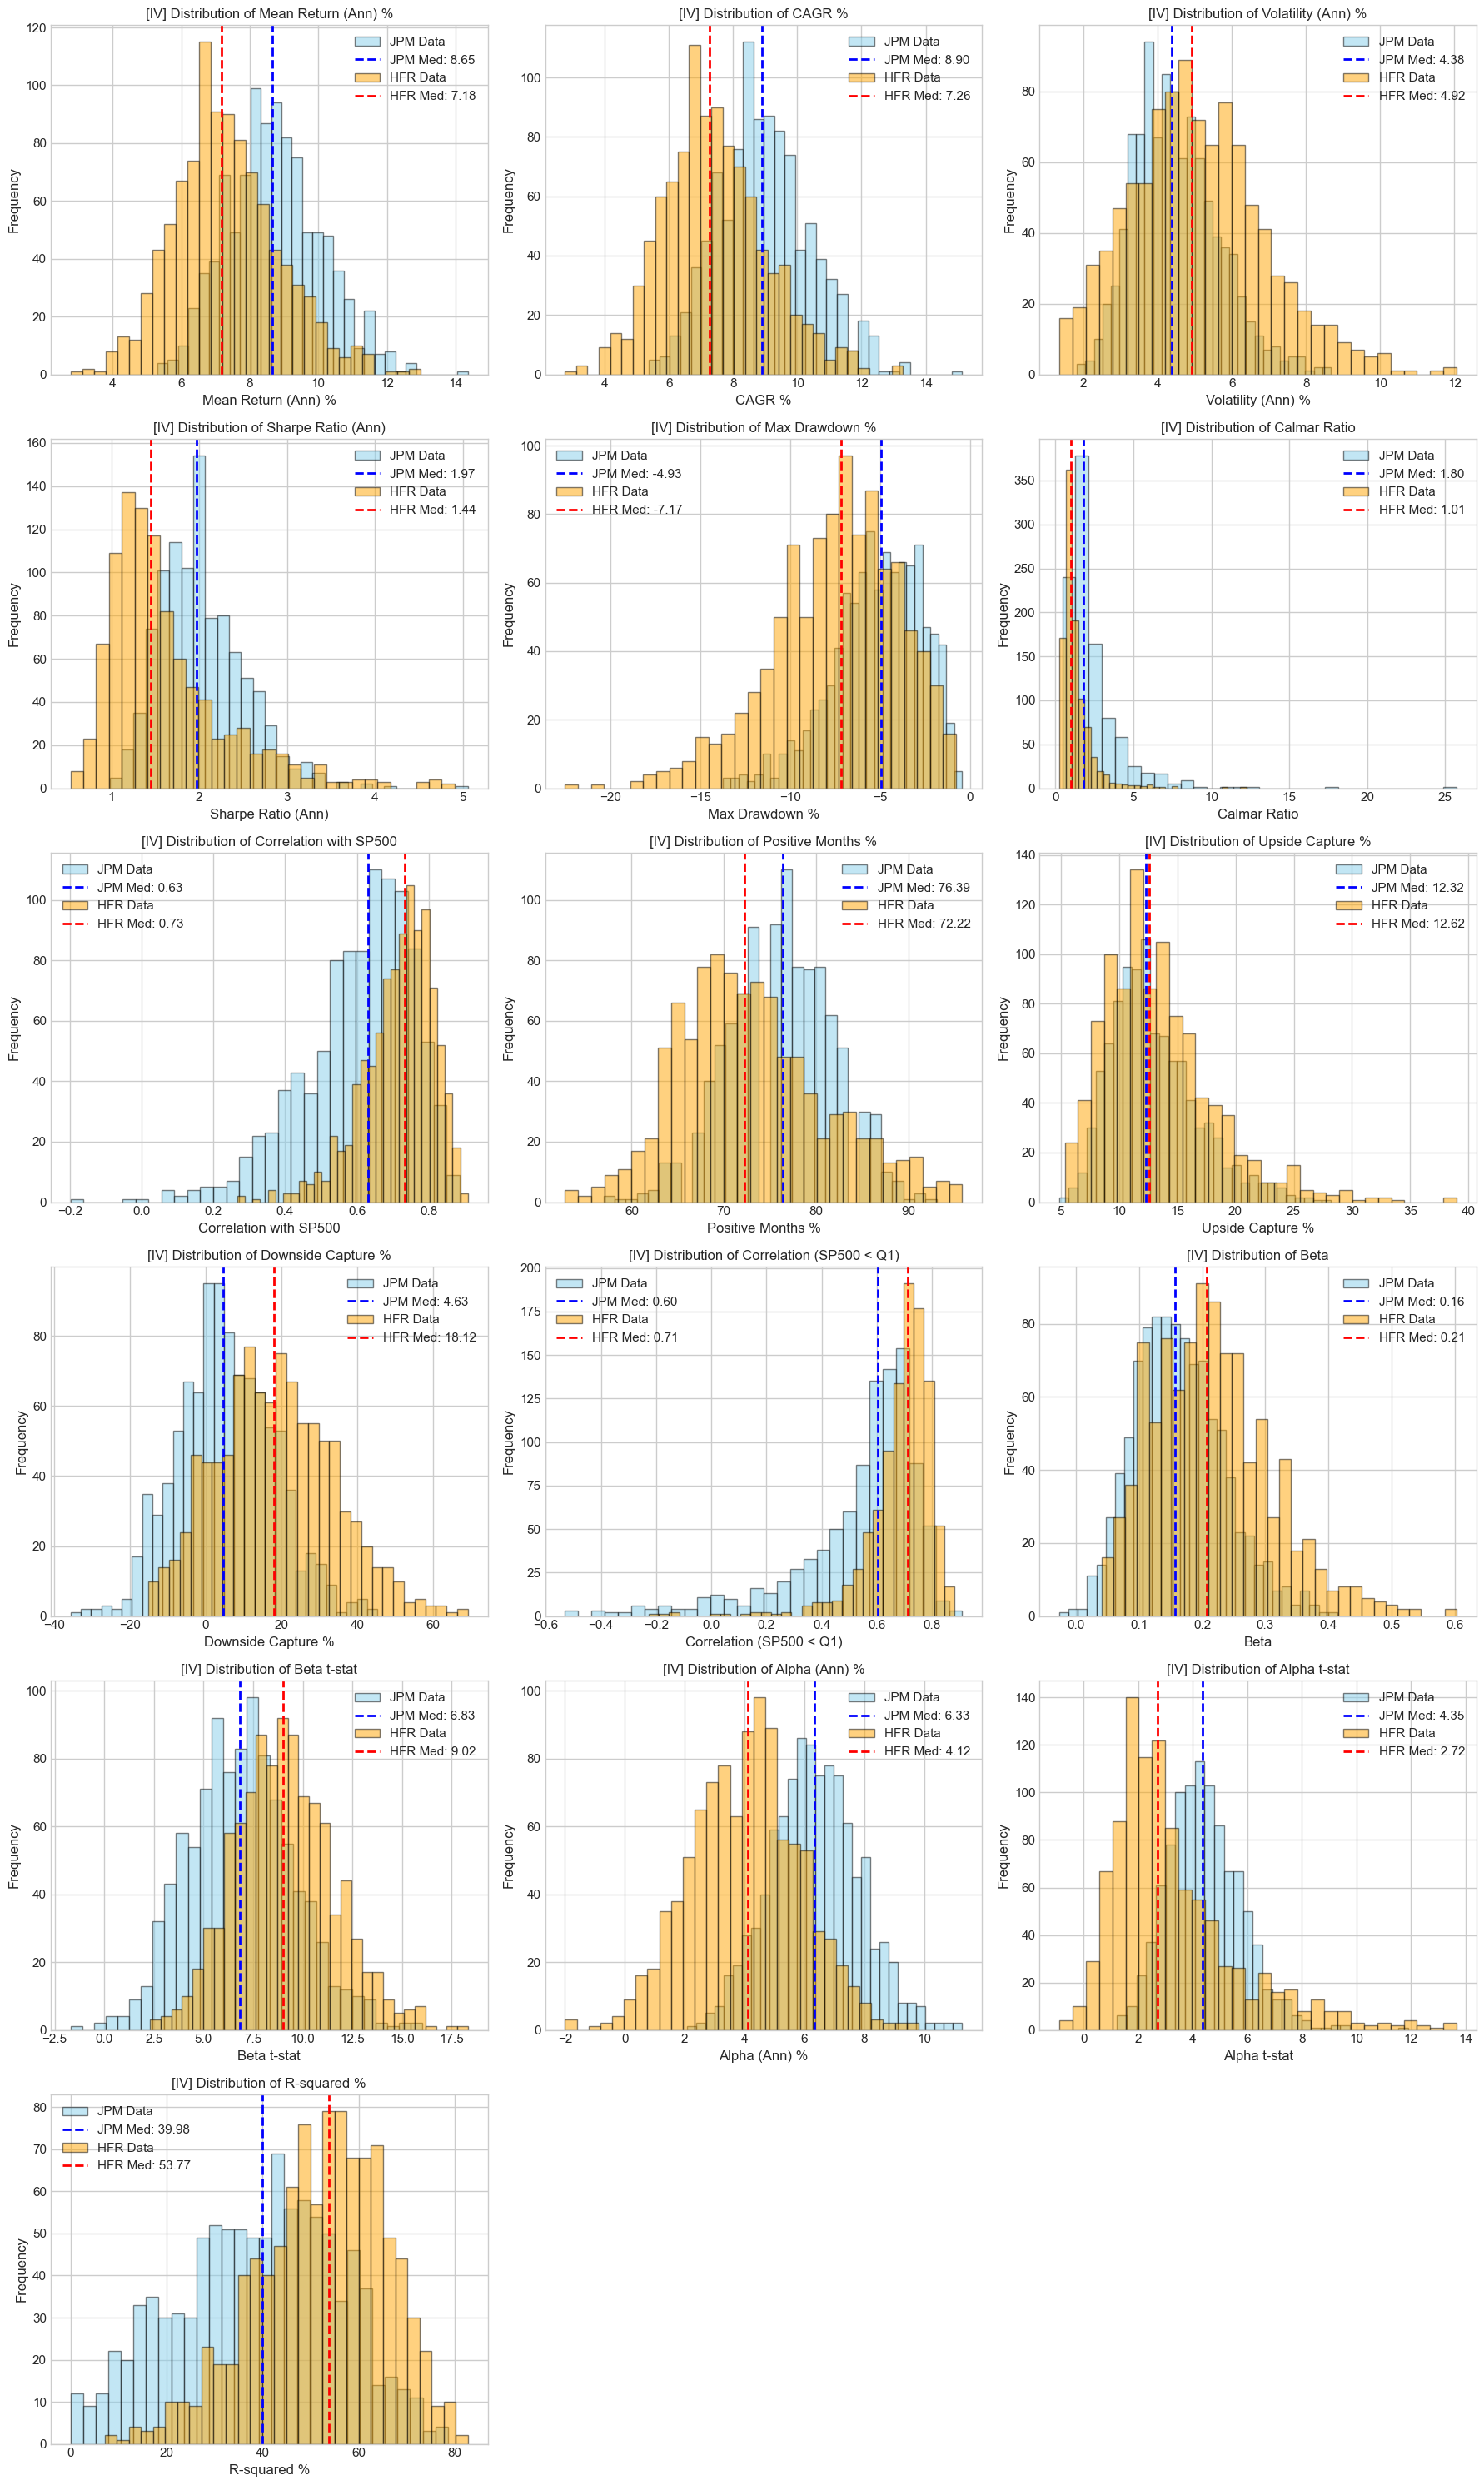

In [165]:
np.random.seed(42)
res_jpm_10_iv = run_bootstrap_n(jpm_period, sp500_period, 10, n_boot=1000, weight_scheme='iv')
res_hfr_10_iv = run_bootstrap_n(hfr_period, sp500_period, 10, n_boot=1000, weight_scheme='iv')

plot_distributions(res_jpm_10_iv, res_hfr_10_iv, title_prefix="[IV]")

Scaling sizes (IV): 100%|██████████| 13/13 [00:32<00:00,  2.53s/it]


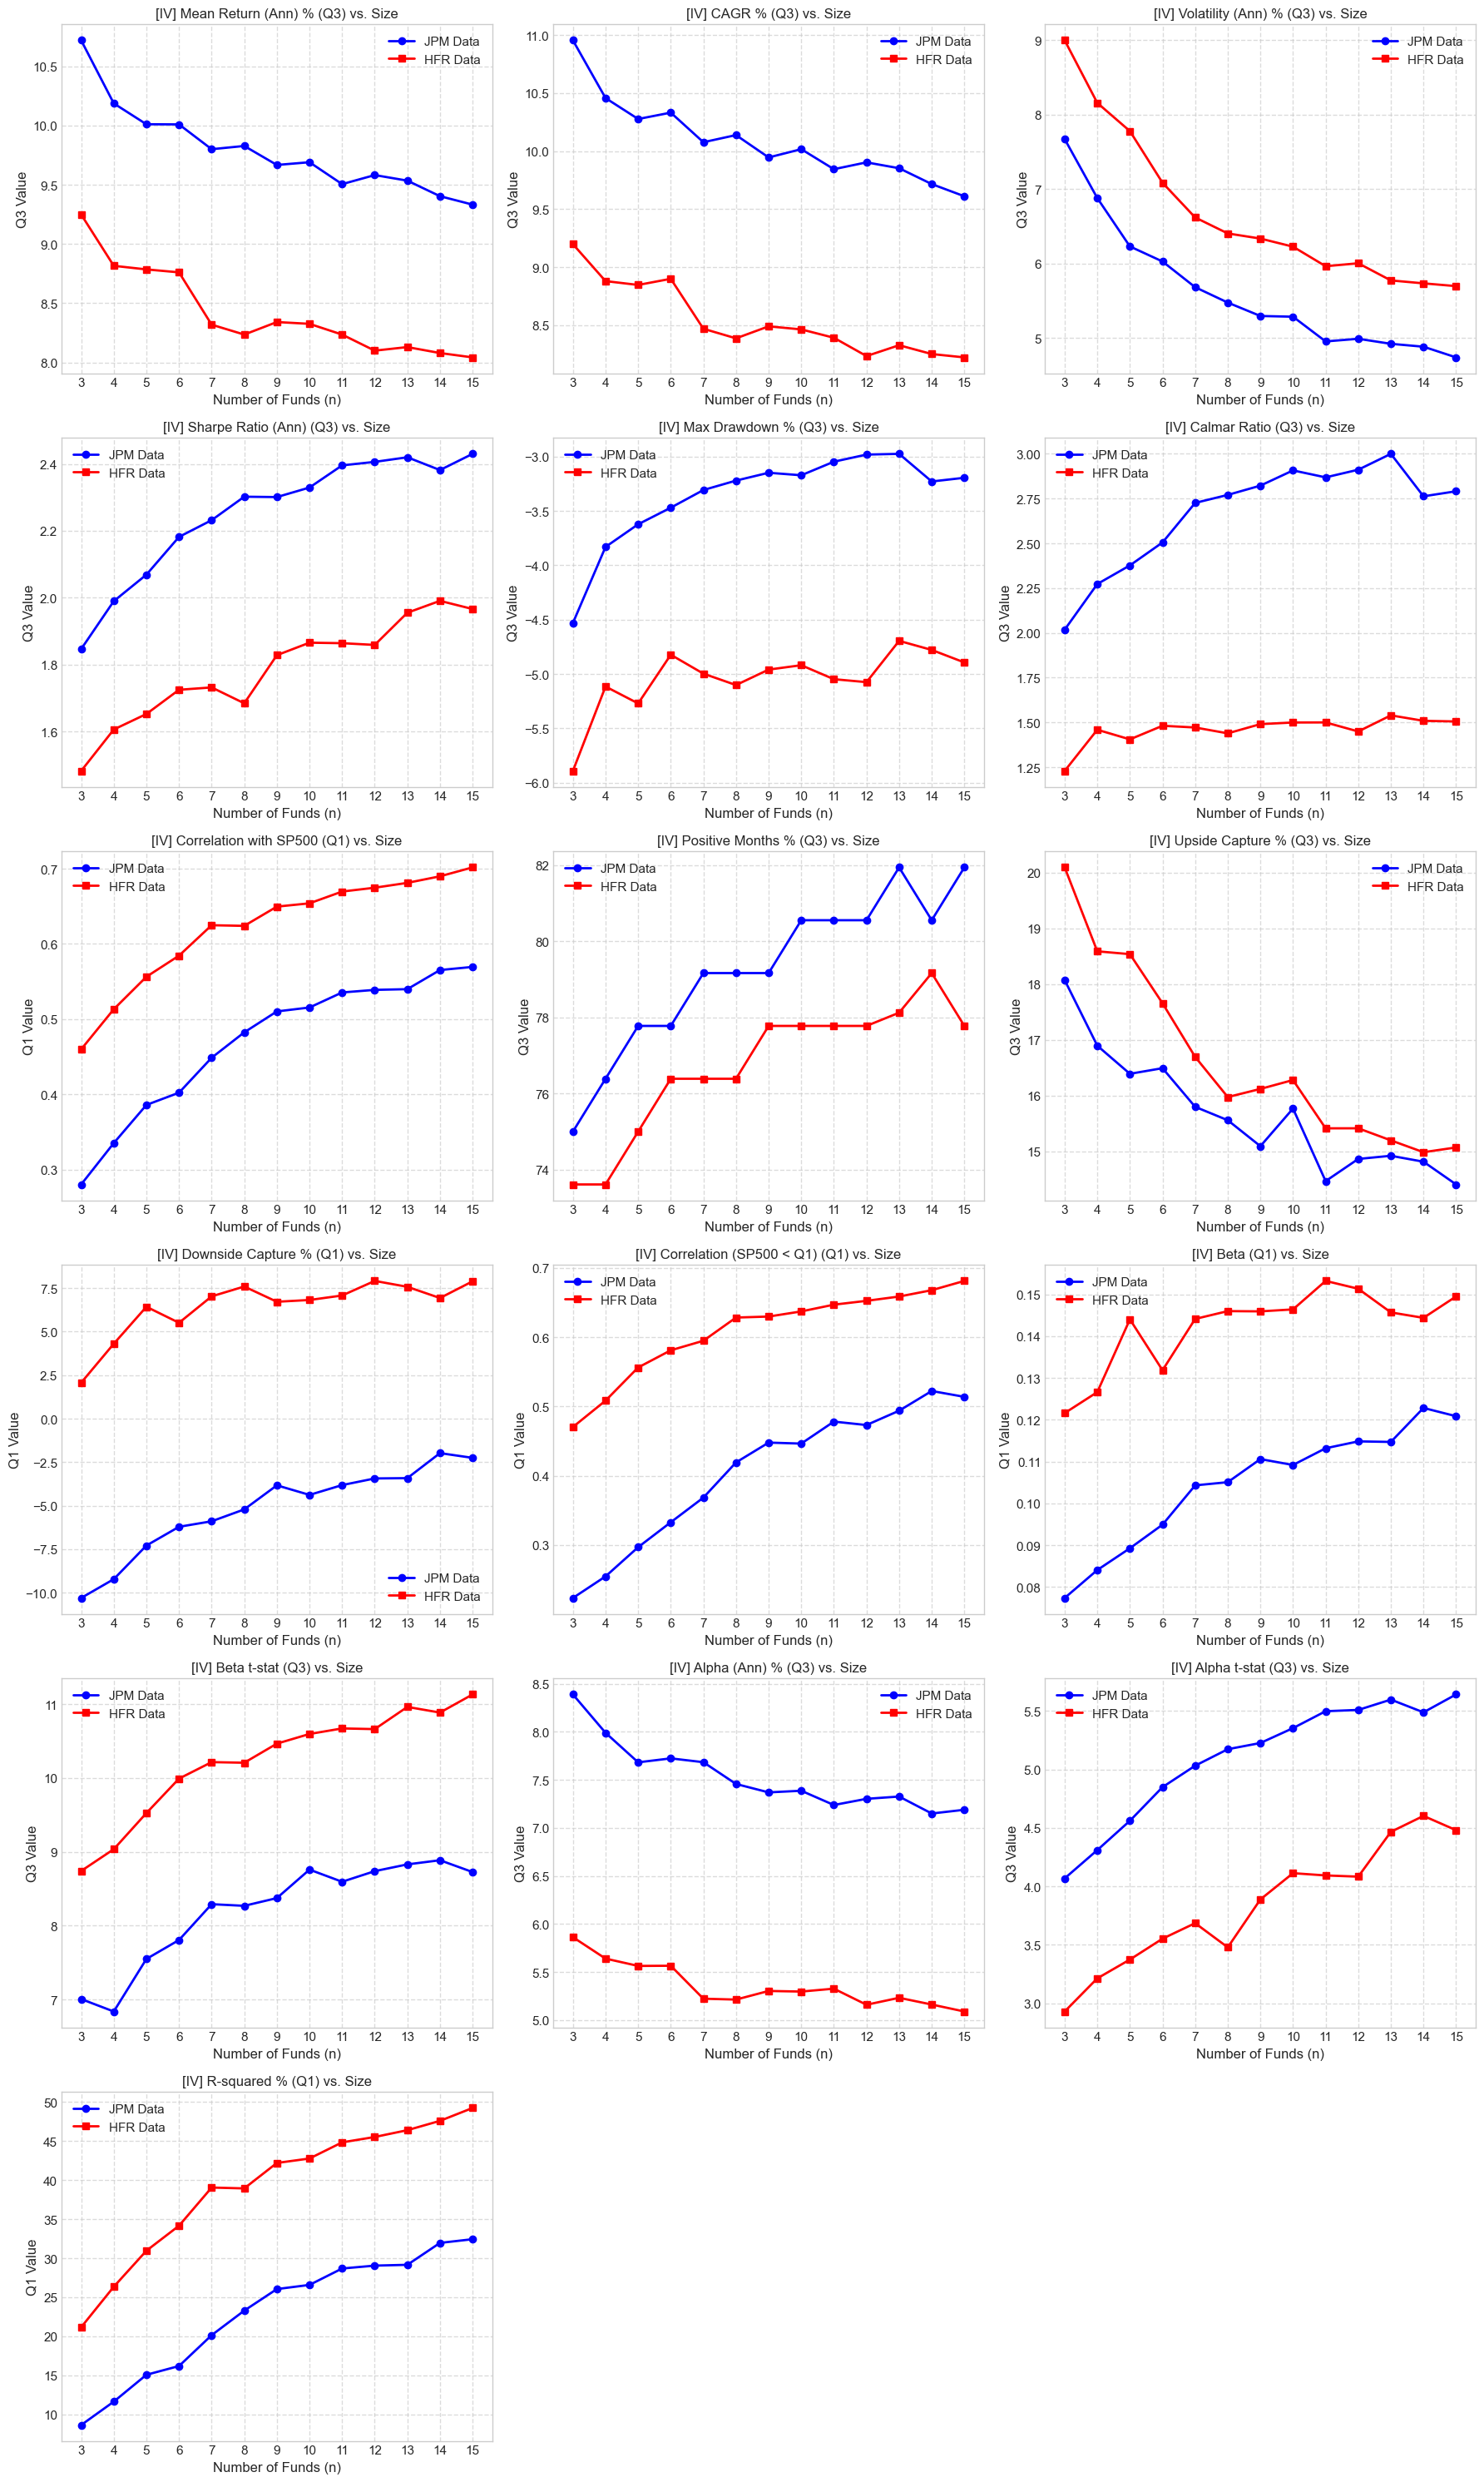

In [166]:
np.random.seed(42)
df_q_jpm_iv, df_q_hfr_iv = run_scaling_analysis(jpm_period, hfr_period, sp500_period, weight_scheme='iv')
plot_scaling(df_q_jpm_iv, df_q_hfr_iv, title_prefix="[IV]")

## 3. Summary Comparison Table (n=10)

Below is a unified table summarizing the distribution (1st Quartile, Median, 3rd Quartile) for every metric across both Datasets (JPM vs HFR) and both Weighting Schemes (Equal Weight vs Inverse Volatility).

In [167]:
def create_comparison_table(res_jpm_ew, res_hfr_ew, res_jpm_iv, res_hfr_iv):
    datasets = {
        ('JPM', 'EW'): res_jpm_ew,
        ('HFR', 'EW'): res_hfr_ew,
        ('JPM', 'IV'): res_jpm_iv,
        ('HFR', 'IV'): res_hfr_iv
    }
    
    summary_data = {}
    
    for (data_name, weight_scheme), df in datasets.items():
        if df.empty:
            continue
            
        for metric in metrics_to_plot:
            q1 = df[metric].quantile(0.25)
            median = df[metric].median()
            q3 = df[metric].quantile(0.75)
            
            summary_data[(data_name, weight_scheme, 'Q1', metric)] = q1
            summary_data[(data_name, weight_scheme, 'Median', metric)] = median
            summary_data[(data_name, weight_scheme, 'Q3', metric)] = q3
            
    # Convert to a multi-index Series
    summary_series = pd.Series(summary_data)
    summary_series.index.names = ['Dataset', 'Weighting', 'Statistic', 'Metric']
    
    # Unstack the columns we want at the top
    summary_df = summary_series.unstack(level=['Dataset', 'Weighting', 'Statistic'])
    
    # Reorder columns explicitly for logical readability
    summary_df = summary_df.reindex(columns=['JPM', 'HFR'], level='Dataset')
    summary_df = summary_df.reindex(columns=['EW', 'IV'], level='Weighting')
    summary_df = summary_df.reindex(columns=['Q1', 'Median', 'Q3'], level='Statistic')
    
    # Reorder index exactly as defined in metrics_to_plot
    summary_df = summary_df.reindex(metrics_to_plot)
    
    return summary_df

comparison_table = create_comparison_table(res_jpm_10_ew, res_hfr_10_ew, res_jpm_10_iv, res_hfr_10_iv)

# Display standard formatted table
display(comparison_table.round(2))

Dataset                     JPM                                       HFR  \
Weighting                    EW                   IV                   EW   
Statistic                    Q1 Median     Q3     Q1 Median     Q3     Q1   
Metric                                                                      
Mean Return (Ann) %        8.74   9.81  10.97   7.81   8.65   9.58   7.44   
CAGR %                     8.90  10.08  11.32   8.01   8.90   9.87   7.36   
Volatility (Ann) %         5.02   6.14   7.29   3.68   4.38   5.21   6.85   
Sharpe Ratio (Ann)         1.39   1.61   1.88   1.69   1.97   2.32   0.92   
Max Drawdown %            -9.80  -7.18  -5.05  -6.69  -4.93  -3.25 -14.76   
Calmar Ratio               1.03   1.38   1.99   1.31   1.80   2.76   0.57   
Correlation with SP500     0.55   0.68   0.76   0.52   0.63   0.72   0.66   
Positive Months %         66.67  70.83  75.00  72.22  76.39  80.56  62.50   
Upside Capture %          13.79  17.47  22.04  10.34  12.32  15.18  16.56   
Downside Capture %         5.94  17.46  28.95  -3.50   4.63  13.74  27.22   
Correlation (SP500 < Q1)   0.44   0.62   0.71   0.46   0.60   0.69   0.65   
Beta                       0.17   0.24   0.31   0.11   0.16   0.21   0.28   
Beta t-stat                5.52   7.74   9.80   5.12   6.83   8.56   7.40   
Alpha (Ann) %              5.22   6.34   7.44   5.36   6.33   7.33   1.92   
Alpha t-stat               2.56   3.26   4.07   3.48   4.35   5.27   0.82   
R-squared %               30.30  46.12  57.87  27.27  39.98  51.16  43.92   

Dataset                                                      
Weighting                                  IV                
Statistic                Median     Q3     Q1 Median     Q3  
Metric                                                       
Mean Return (Ann) %        8.62  10.08   6.29   7.18   8.24  
CAGR %                     8.59  10.14   6.34   7.26   8.38  
Volatility (Ann) %         8.13   9.53   3.82   4.92   6.14  
Sharpe Ratio (Ann)         1.07   1.25   1.17   1.44   1.90  
Max Drawdown %           -12.07  -9.31  -9.71  -7.17  -4.96  
Calmar Ratio               0.73   0.97   0.75   1.01   1.53  
Correlation with SP500     0.74   0.80   0.66   0.73   0.79  
Positive Months %         65.28  69.44  68.06  72.22  77.78  
Upside Capture %          20.40  26.15  10.04  12.62  15.83  
Downside Capture %        38.19  49.61   7.53  18.12  28.81  
Correlation (SP500 < Q1)   0.72   0.78   0.65   0.71   0.76  
Beta                       0.35   0.44   0.14   0.21   0.27  
Beta t-stat                9.19  11.23   7.31   9.02  10.73  
Alpha (Ann) %              3.33   4.80   2.77   4.12   5.19  
Alpha t-stat               1.42   2.09   1.75   2.72   4.15  
R-squared %               54.70  64.32  43.27  53.77  62.21